# Beat-timing prototype

This notebook tests a two-layer beat-candidate pipeline on reproducible synthetic data:

1. **Layer 1:** estimate a local baseline, calculate relative prominence, and detect local peaks.
2. **Layer 2:** retain candidates supported by an approximately periodic beat interval.

The synthetic spikes include timing jitter, so the detector is tested against a slightly imperfect fixed-BPM grid.

## 1. Imports

In [10]:
from __future__ import annotations

from collections.abc import Callable
from typing import Any

import matplotlib.pyplot as plt
import numpy as np

## 2. Synthetic data generators

In [11]:
def generate_random_baseline(
    length: int,
    low: int = 5,
    high: int = 15,
    seed: int = 42,
) -> np.ndarray:
    """Generate a reproducible random integer baseline."""
    if length <= 0:
        raise ValueError("length must be positive.")
    if low > high:
        raise ValueError("low must not exceed high.")

    rng = np.random.default_rng(seed)
    return rng.integers(low, high + 1, size=length).astype(float)


def add_jittered_spikes(
    data: np.ndarray,
    first_spike: int,
    interval: int,
    jitter: int = 2,
    spike_value: float = 16,
    seed: int = 42,
) -> tuple[np.ndarray, list[int]]:
    """Place approximately periodic fixed-height spikes into a copy of data."""
    if interval <= 0:
        raise ValueError("interval must be positive.")
    if jitter < 0:
        raise ValueError("jitter cannot be negative.")

    rng = np.random.default_rng(seed)
    result = np.asarray(data, dtype=float).copy()
    true_spikes: list[int] = []

    position = first_spike
    while position < len(result):
        jittered = int(position + rng.integers(-jitter, jitter + 1))
        if 0 <= jittered < len(result):
            result[jittered] = spike_value
            true_spikes.append(jittered)
        position += interval

    return result, true_spikes

## 3. Layer 1: baselines, scores, and peak detection

In [12]:
def convolution_baseline(
    data: np.ndarray,
    window_size: int = 21,
) -> np.ndarray:
    """Centered uniform moving average; the candidate contributes to its own baseline."""
    x = np.asarray(data, dtype=float)

    if window_size < 1 or window_size % 2 == 0:
        raise ValueError("window_size must be a positive odd integer.")

    kernel = np.ones(window_size, dtype=float) / window_size
    half = window_size // 2
    padded = np.pad(x, pad_width=half, mode="reflect")
    return np.convolve(padded, kernel, mode="valid")


def leave_window_baseline(
    data: np.ndarray,
    context_size: int = 10,
    gap_size: int = 2,
) -> np.ndarray:
    """Average left and right context while excluding the center and a surrounding gap."""
    x = np.asarray(data, dtype=float)
    n = len(x)

    if context_size < 1:
        raise ValueError("context_size must be at least 1.")
    if gap_size < 0:
        raise ValueError("gap_size cannot be negative.")

    baseline = np.empty(n, dtype=float)

    for i in range(n):
        left = x[max(0, i - gap_size - context_size):max(0, i - gap_size)]
        right = x[min(n, i + gap_size + 1):min(n, i + gap_size + context_size + 1)]
        surrounding = np.concatenate([left, right])
        baseline[i] = surrounding.mean() if surrounding.size else x[i]

    return baseline


def relative_score(
    data: np.ndarray,
    baseline: np.ndarray,
    epsilon: float = 1e-9,
) -> np.ndarray:
    """Relative prominence: (data - baseline) / |baseline|."""
    x = np.asarray(data, dtype=float)
    b = np.asarray(baseline, dtype=float)

    if x.shape != b.shape:
        raise ValueError("data and baseline must have the same shape.")

    return (x - b) / (np.abs(b) + epsilon)


def detect_peaks(
    data: np.ndarray,
    scores: np.ndarray,
    threshold: float = 0.2,
    minimum_distance: int = 5,
) -> list[int]:
    """Keep local maxima above threshold, suppressing weaker nearby candidates."""
    x = np.asarray(data, dtype=float)
    s = np.asarray(scores, dtype=float)

    if x.shape != s.shape:
        raise ValueError("data and scores must have the same shape.")
    if minimum_distance < 1:
        raise ValueError("minimum_distance must be at least 1.")

    candidates: list[int] = []
    for i in range(len(x)):
        left = x[i - 1] if i > 0 else -np.inf
        right = x[i + 1] if i < len(x) - 1 else -np.inf
        if x[i] >= left and x[i] > right and s[i] > threshold:
            candidates.append(i)

    selected: list[int] = []
    for index in sorted(candidates, key=lambda i: s[i], reverse=True):
        if all(abs(index - chosen) >= minimum_distance for chosen in selected):
            selected.append(index)

    return sorted(selected)

## 4. Evaluation and plotting helpers

In [13]:
def evaluate_detection(
    true_indices: list[int],
    detected_indices: list[int],
    tolerance: int = 0,
) -> dict[str, float | int]:
    """One-to-one matching of predictions to ground truth within tolerance."""
    unmatched_true = set(true_indices)
    matched_detected: set[int] = set()

    for detected in detected_indices:
        possible = [
            true_index
            for true_index in unmatched_true
            if abs(detected - true_index) <= tolerance
        ]
        if possible:
            closest = min(possible, key=lambda true_index: abs(detected - true_index))
            unmatched_true.remove(closest)
            matched_detected.add(detected)

    tp = len(matched_detected)
    fp = len(detected_indices) - tp
    fn = len(unmatched_true)

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    return {
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def print_evaluation(name: str, result: dict[str, float | int]) -> None:
    print(name)
    print("-" * len(name))
    for key, value in result.items():
        print(f"{key:16s}: {value:.3f}" if isinstance(value, float) else f"{key:16s}: {value}")
    print()


def readable_function_name(function: Callable[..., Any]) -> str:
    return function.__name__.replace("_", " ").title()


def format_parameters(parameters: dict[str, Any]) -> str:
    if not parameters:
        return ""
    values = ", ".join(f"{key}={value}" for key, value in parameters.items())
    return f" ({values})"


def evaluate_and_plot_pipeline(
    data: np.ndarray,
    true_spikes: list[int],
    baseline_function: Callable[..., np.ndarray],
    score_function: Callable[..., np.ndarray],
    peak_function: Callable[..., list[int]],
    plot_start: int = 0,
    plot_end: int = 300,
    tolerance: int = 0,
    baseline_kwargs: dict[str, Any] | None = None,
    score_kwargs: dict[str, Any] | None = None,
    peak_kwargs: dict[str, Any] | None = None,
) -> tuple[np.ndarray, np.ndarray, list[int], dict[str, float | int]]:
    """Compute, evaluate, and plot one complete Layer-1 pipeline."""
    baseline_kwargs = baseline_kwargs or {}
    score_kwargs = score_kwargs or {}
    peak_kwargs = peak_kwargs or {}

    x = np.asarray(data, dtype=float)
    baseline = baseline_function(x, **baseline_kwargs)
    scores = score_function(x, baseline, **score_kwargs)
    detected_peaks = peak_function(x, scores, **peak_kwargs)

    result = evaluate_detection(true_spikes, detected_peaks, tolerance=tolerance)

    baseline_name = readable_function_name(baseline_function)
    score_name = readable_function_name(score_function)
    peak_name = readable_function_name(peak_function)

    pipeline_name = (
        baseline_name + format_parameters(baseline_kwargs)
        + " → " + score_name + format_parameters(score_kwargs)
        + " → " + peak_name + format_parameters(peak_kwargs)
    )

    print_evaluation(pipeline_name, result)

    start = max(0, plot_start)
    end = min(plot_end, len(x))
    if start >= end:
        raise ValueError("plot_start must be smaller than plot_end.")

    indices = np.arange(start, end)
    visible_true = [i for i in true_spikes if start <= i < end]
    visible_detected = [i for i in detected_peaks if start <= i < end]

    plt.figure(figsize=(14, 5))
    plt.plot(indices, x[start:end], label="Data")
    plt.plot(indices, baseline[start:end], label=baseline_name)
    plt.scatter(
        visible_detected,
        x[visible_detected],
        marker="o",
        s=90,
        label="Detected peaks",
        zorder=4,
    )
    plt.scatter(
        visible_true,
        x[visible_true],
        marker="x",
        s=110,
        linewidths=2,
        label="True spikes",
        zorder=5,
    )
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title(pipeline_name)
    plt.legend()
    plt.show()

    return baseline, scores, detected_peaks, result

## 5. Layer 2: periodic-support filtering

In [14]:
def periodic_support_scores(
    detected_peaks: list[int],
    expected_interval: int,
    tolerance: int = 3,
    max_multiples: int = 3,
) -> dict[int, int]:
    """Count candidate neighbors near ±k × expected_interval."""
    peaks = np.asarray(detected_peaks, dtype=int)
    support_scores: dict[int, int] = {}

    for peak in peaks:
        support = 0
        for multiple in range(1, max_multiples + 1):
            distance = multiple * expected_interval
            for direction in (-1, 1):
                target = peak + direction * distance
                if np.any(np.abs(peaks - target) <= tolerance):
                    support += 1
        support_scores[int(peak)] = support

    return support_scores


def periodic_filter(
    detected_peaks: list[int],
    expected_interval: int,
    tolerance: int = 3,
    max_multiples: int = 3,
    minimum_support: int = 2,
) -> tuple[list[int], dict[int, int]]:
    """Keep Layer-1 candidates with enough periodic support."""
    support_scores = periodic_support_scores(
        detected_peaks=detected_peaks,
        expected_interval=expected_interval,
        tolerance=tolerance,
        max_multiples=max_multiples,
    )
    filtered = [
        peak for peak in detected_peaks
        if support_scores[peak] >= minimum_support
    ]
    return filtered, support_scores


def plot_periodic_filter_result(
    data: np.ndarray,
    true_spikes: list[int],
    layer1_peaks: list[int],
    layer2_peaks: list[int],
    support_scores: dict[int, int],
    plot_start: int = 0,
    plot_end: int = 300,
) -> None:
    """Compare Layer-1 proposals with Layer-2 survivors."""
    x = np.asarray(data, dtype=float)
    start = max(0, plot_start)
    end = min(plot_end, len(x))
    indices = np.arange(start, end)

    visible_true = [i for i in true_spikes if start <= i < end]
    visible_layer1 = [i for i in layer1_peaks if start <= i < end]
    visible_layer2 = [i for i in layer2_peaks if start <= i < end]

    plt.figure(figsize=(14, 5))
    plt.plot(indices, x[start:end], label="Data")
    plt.scatter(
        visible_layer1,
        x[visible_layer1],
        marker="o",
        facecolors="none",
        s=80,
        label="Layer 1 candidates",
    )
    plt.scatter(
        visible_layer2,
        x[visible_layer2],
        marker="o",
        s=65,
        label="Layer 2 periodic peaks",
    )
    plt.scatter(
        visible_true,
        x[visible_true],
        marker="x",
        s=110,
        linewidths=2,
        label="True spikes",
    )

    for peak in visible_layer2:
        plt.annotate(
            str(support_scores[peak]),
            xy=(peak, x[peak]),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )

    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.title("Layer 1 candidates → periodic-support filter")
    plt.legend()
    plt.show()

## 6. Define the synthetic experiment

In [15]:
DATA_LENGTH = 10_000
BEAT_INTERVAL = 50
FIRST_SPIKE = 25

BASELINE_LOW = 5
BASELINE_HIGH = 15
JITTER = 2
SPIKE_VALUE = 16
SEED = 420

base_data = generate_random_baseline(
    length=DATA_LENGTH,
    low=BASELINE_LOW,
    high=BASELINE_HIGH,
    seed=SEED,
)

data, true_spikes = add_jittered_spikes(
    data=base_data,
    first_spike=FIRST_SPIKE,
    interval=BEAT_INTERVAL,
    jitter=JITTER,
    spike_value=SPIKE_VALUE,
    seed=SEED,
)

print("Number of points:", len(data))
print("Number of true spikes:", len(true_spikes))
print("First true spike indices:", true_spikes[:10])
print("First jitter amounts:", [
    actual - expected
    for actual, expected in zip(
        true_spikes[:10],
        range(FIRST_SPIKE, FIRST_SPIKE + 10 * BEAT_INTERVAL, BEAT_INTERVAL),
    )
])

Number of points: 10000
Number of true spikes: 200
First true spike indices: [26, 76, 123, 177, 227, 277, 323, 375, 424, 476]
First jitter amounts: [1, 1, -2, 2, 2, 2, -2, 0, -1, 1]


## 7. Run and compare Layer 1

Convolution Baseline (window_size=21) → Relative Score → Detect Peaks (threshold=0.2, minimum_distance=5)
---------------------------------------------------------------------------------------------------------
true_positives  : 199
false_positives : 1060
false_negatives : 1
precision       : 0.158
recall          : 0.995
f1              : 0.273



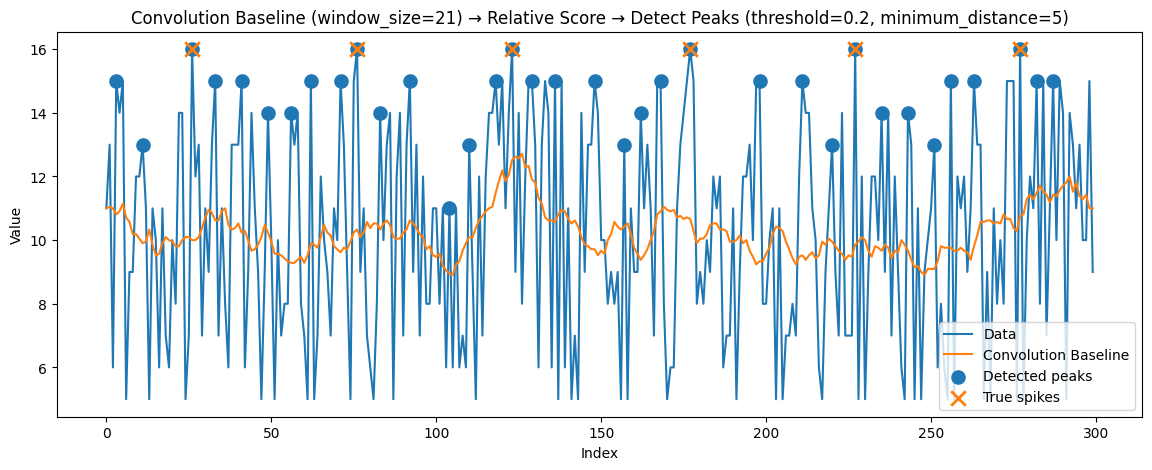

Leave Window Baseline (context_size=10, gap_size=2) → Relative Score → Detect Peaks (threshold=0.2, minimum_distance=5)
-----------------------------------------------------------------------------------------------------------------------
true_positives  : 192
false_positives : 1030
false_negatives : 8
precision       : 0.157
recall          : 0.960
f1              : 0.270



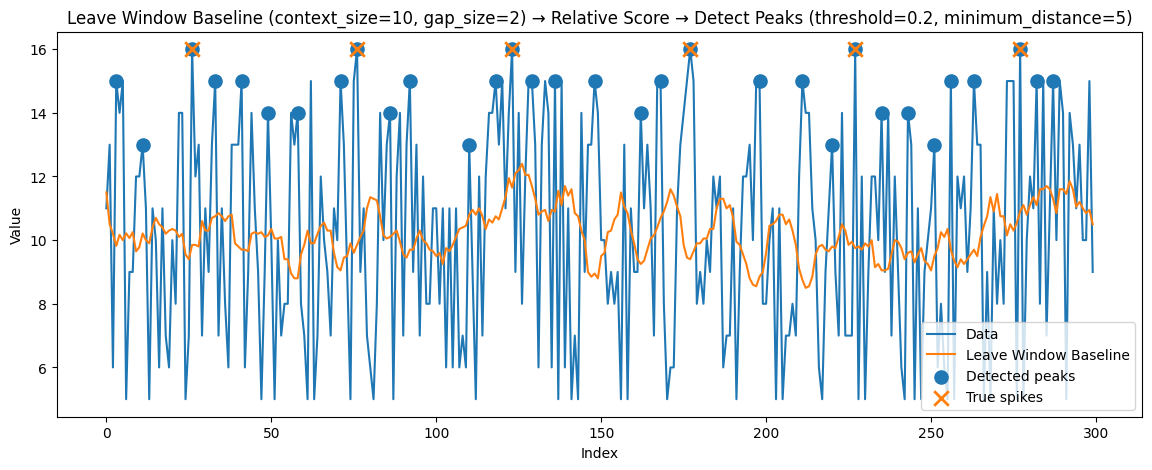

In [16]:
GLOBAL_THRESHOLD = 0.20
GLOBAL_MINIMUM_DISTANCE = 5

conv_baseline, conv_scores, conv_peaks, conv_result = evaluate_and_plot_pipeline(
    data=data,
    true_spikes=true_spikes,
    baseline_function=convolution_baseline,
    score_function=relative_score,
    peak_function=detect_peaks,
    plot_end=300,
    tolerance=0,
    baseline_kwargs={"window_size": 21},
    peak_kwargs={
        "threshold": GLOBAL_THRESHOLD,
        "minimum_distance": GLOBAL_MINIMUM_DISTANCE,
    },
)

leave_baseline, leave_scores, leave_peaks, leave_result = evaluate_and_plot_pipeline(
    data=data,
    true_spikes=true_spikes,
    baseline_function=leave_window_baseline,
    score_function=relative_score,
    peak_function=detect_peaks,
    plot_end=300,
    tolerance=0,
    baseline_kwargs={"context_size": 10, "gap_size": 2},
    peak_kwargs={
        "threshold": GLOBAL_THRESHOLD,
        "minimum_distance": GLOBAL_MINIMUM_DISTANCE,
    },
)

## 8. Threshold sweep

In [17]:
for threshold in [0.20, 0.25, 0.30, 0.40, 0.50]:
    peaks = detect_peaks(
        data=data,
        scores=conv_scores,
        threshold=threshold,
        minimum_distance=GLOBAL_MINIMUM_DISTANCE,
    )
    result = evaluate_detection(true_spikes, peaks, tolerance=0)
    print(
        f"threshold={threshold:.2f} "
        f"precision={result['precision']:.3f} "
        f"recall={result['recall']:.3f} "
        f"f1={result['f1']:.3f}"
    )

threshold=0.20 precision=0.158 recall=0.995 f1=0.273
threshold=0.25 precision=0.167 recall=0.995 f1=0.286
threshold=0.30 precision=0.179 recall=0.985 f1=0.303
threshold=0.40 precision=0.243 recall=0.935 f1=0.386
threshold=0.50 precision=0.391 recall=0.725 f1=0.508


## 9. Apply and evaluate Layer 2

Convolution: Layer 1
--------------------
true_positives  : 199
false_positives : 1060
false_negatives : 1
precision       : 0.158
recall          : 0.995
f1              : 0.273

Convolution: after Layer 2
--------------------------
true_positives  : 199
false_positives : 1058
false_negatives : 1
precision       : 0.158
recall          : 0.995
f1              : 0.273

Leave-window: Layer 1
---------------------
true_positives  : 192
false_positives : 1030
false_negatives : 8
precision       : 0.157
recall          : 0.960
f1              : 0.270

Leave-window: after Layer 2
---------------------------
true_positives  : 192
false_positives : 1024
false_negatives : 8
precision       : 0.158
recall          : 0.960
f1              : 0.271



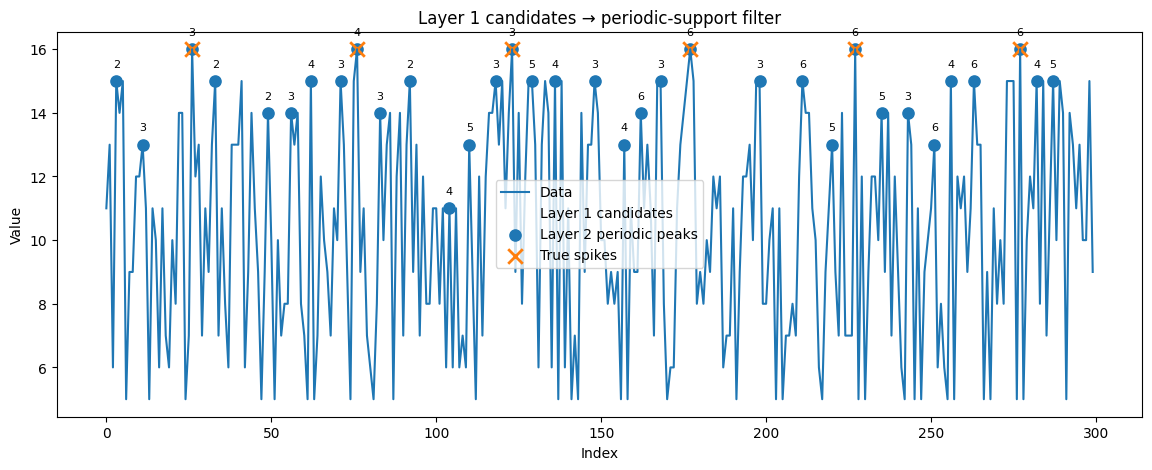

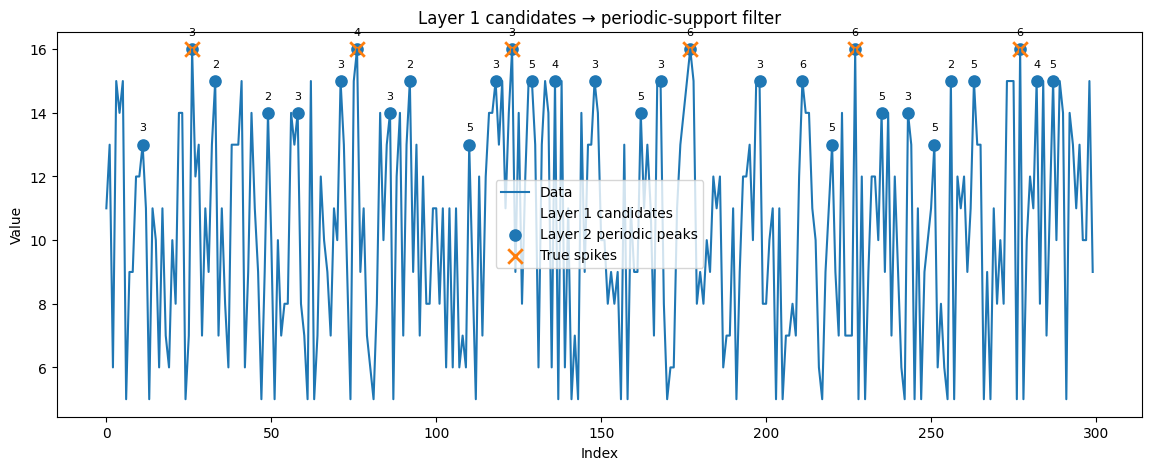

In [18]:
PERIODIC_TOLERANCE = 3
MAX_MULTIPLES = 3
MINIMUM_SUPPORT = 2

conv_periodic_peaks, conv_support = periodic_filter(
    detected_peaks=conv_peaks,
    expected_interval=BEAT_INTERVAL,
    tolerance=PERIODIC_TOLERANCE,
    max_multiples=MAX_MULTIPLES,
    minimum_support=MINIMUM_SUPPORT,
)

leave_periodic_peaks, leave_support = periodic_filter(
    detected_peaks=leave_peaks,
    expected_interval=BEAT_INTERVAL,
    tolerance=PERIODIC_TOLERANCE,
    max_multiples=MAX_MULTIPLES,
    minimum_support=MINIMUM_SUPPORT,
)

print_evaluation(
    "Convolution: Layer 1",
    evaluate_detection(true_spikes, conv_peaks, tolerance=0),
)
print_evaluation(
    "Convolution: after Layer 2",
    evaluate_detection(true_spikes, conv_periodic_peaks, tolerance=0),
)
print_evaluation(
    "Leave-window: Layer 1",
    evaluate_detection(true_spikes, leave_peaks, tolerance=0),
)
print_evaluation(
    "Leave-window: after Layer 2",
    evaluate_detection(true_spikes, leave_periodic_peaks, tolerance=0),
)

plot_periodic_filter_result(
    data=data,
    true_spikes=true_spikes,
    layer1_peaks=conv_peaks,
    layer2_peaks=conv_periodic_peaks,
    support_scores=conv_support,
    plot_end=300,
)

plot_periodic_filter_result(
    data=data,
    true_spikes=true_spikes,
    layer1_peaks=leave_peaks,
    layer2_peaks=leave_periodic_peaks,
    support_scores=leave_support,
    plot_end=300,
)

## 10. Next experiment

The periodic filter currently receives the known interval `BEAT_INTERVAL = 50`. The next research step is to infer that interval from the Layer-1 candidate spacings, rather than supplying it as ground truth.